# 🎮 Online Gaming Behavior — ML Classification Project

**Dataset:** Online Gaming Behavior Dataset  
**Target:** `EngagementLevel` → Low / Medium / High  
**Records:** 40,034 | **Features:** 12  

---

## 📌 Full Pipeline

```
Raw Data
   ↓
EDA & Preprocessing
   ↓
┌─────────────────────────────────────────┐
│         DIMENSION REDUCTION             │
│                                         │
│  Feature Selection:                     │
│    ├── Filter   → Chi2 + ANOVA F-test   │
│    ├── Wrapper  → RFE                   │
│    └── Embedded → Lasso + RF Importance │
│                                         │
│  Feature Extraction:                    │
│    ├── PCA (unsupervised)               │
│    └── LDA (supervised)                 │
└─────────────────────────────────────────┘
   ↓
Models: Random Forest · SVM · KNN
   ↓
Evaluation & Comparison
```

---
## 1️⃣ Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest, chi2, f_classif,       # Filter
    RFE,                                 # Wrapper
    SelectFromModel                      # Embedded
)
from sklearn.linear_model import LogisticRegression   # Embedded (Lasso)

# Feature Extraction
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


---
## 2️⃣ Data Loading & Exploration (EDA)

In [2]:
df = pd.read_csv('online_gaming_behavior_dataset.csv')
print(f'Shape     : {df.shape}')
print(f'Features  : {df.shape[1]-1}')
print(f'Records   : {df.shape[0]:,}')
df.head()

Shape     : (40034, 13)
Features  : 12
Records   : 40,034


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
# Missing values & dtypes
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'nulls'  : df.isnull().sum(),
    'null_%' : (df.isnull().sum() / len(df) * 100).round(2),
    'unique' : df.nunique()
})
print(info)
print(f'\n✅ Total missing values: {df.isnull().sum().sum()}')

                             dtype  nulls  null_%  unique
PlayerID                     int64      0     0.0   40034
Age                          int64      0     0.0      35
Gender                      object      0     0.0       2
Location                    object      0     0.0       4
GameGenre                   object      0     0.0       5
PlayTimeHours              float64      0     0.0   40034
InGamePurchases              int64      0     0.0       2
GameDifficulty              object      0     0.0       3
SessionsPerWeek              int64      0     0.0      20
AvgSessionDurationMinutes    int64      0     0.0     170
PlayerLevel                  int64      0     0.0      99
AchievementsUnlocked         int64      0     0.0      50
EngagementLevel             object      0     0.0       3

✅ Total missing values: 0


In [4]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.000000,29016.500000,11556.964675,9000.000000,19008.250000,29016.500000,39024.750000,49033.000000
Age,40034.000000,31.992531,10.043227,15.000000,23.000000,32.000000,41.000000,49.000000
PlayTimeHours,40034.000000,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.000000,0.200854,0.400644,0.000000,0.000000,0.000000,0.000000,1.000000
SessionsPerWeek,40034.000000,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000
AvgSessionDurationMinutes,40034.000000,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000
PlayerLevel,40034.000000,49.655568,28.588379,1.000000,25.000000,49.000000,74.000000,99.000000
AchievementsUnlocked,40034.000000,24.526477,14.430726,0.000000,12.000000,25.000000,37.000000,49.000000


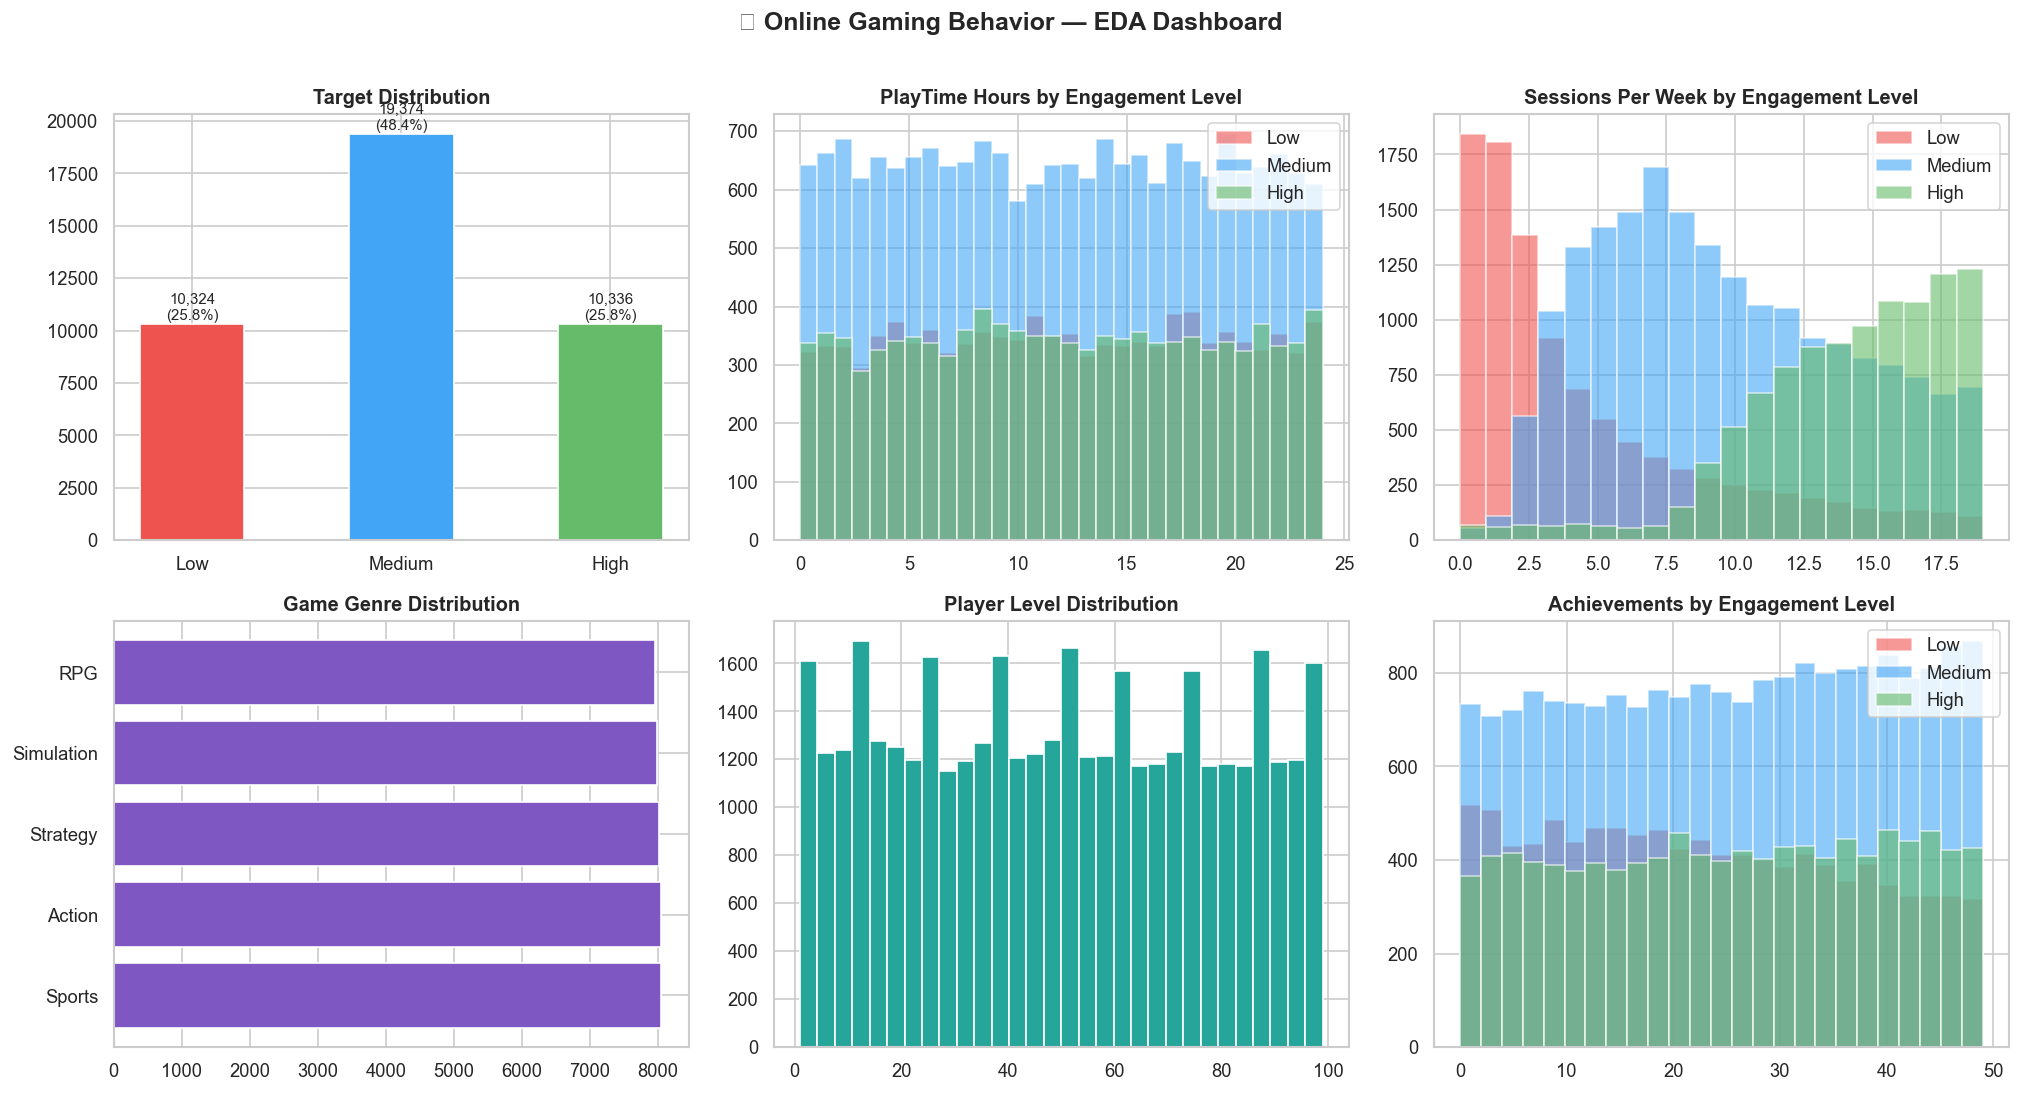

In [5]:
# ── EDA Dashboard ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
order = ['Low', 'Medium', 'High']
palette = {'Low':'#ef5350','Medium':'#42a5f5','High':'#66bb6a'}

# 1. Target distribution
counts = df['EngagementLevel'].value_counts()[order]
axes[0,0].bar(order, counts, color=[palette[k] for k in order], edgecolor='white', width=0.5)
axes[0,0].set_title('Target Distribution', fontweight='bold')
for i,(k,v) in enumerate(counts.items()):
    axes[0,0].text(i, v+200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# 2. PlayTime by Level
for lvl in order:
    axes[0,1].hist(df[df['EngagementLevel']==lvl]['PlayTimeHours'],
                   bins=30, alpha=0.6, label=lvl, color=palette[lvl])
axes[0,1].set_title('PlayTime Hours by Engagement Level', fontweight='bold')
axes[0,1].legend()

# 3. Sessions per week
for lvl in order:
    axes[0,2].hist(df[df['EngagementLevel']==lvl]['SessionsPerWeek'],
                   bins=20, alpha=0.6, label=lvl, color=palette[lvl])
axes[0,2].set_title('Sessions Per Week by Engagement Level', fontweight='bold')
axes[0,2].legend()

# 4. Game Genre
gc = df['GameGenre'].value_counts()
axes[1,0].barh(gc.index, gc.values, color='#7e57c2', edgecolor='white')
axes[1,0].set_title('Game Genre Distribution', fontweight='bold')

# 5. PlayerLevel distribution
axes[1,1].hist(df['PlayerLevel'], bins=30, color='#26a69a', edgecolor='white')
axes[1,1].set_title('Player Level Distribution', fontweight='bold')

# 6. Achievements by Engagement
for lvl in order:
    axes[1,2].hist(df[df['EngagementLevel']==lvl]['AchievementsUnlocked'],
                   bins=25, alpha=0.6, label=lvl, color=palette[lvl])
axes[1,2].set_title('Achievements by Engagement Level', fontweight='bold')
axes[1,2].legend()

plt.suptitle('🎮 Online Gaming Behavior — EDA Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_eda_dashboard.png', bbox_inches='tight')
plt.show()

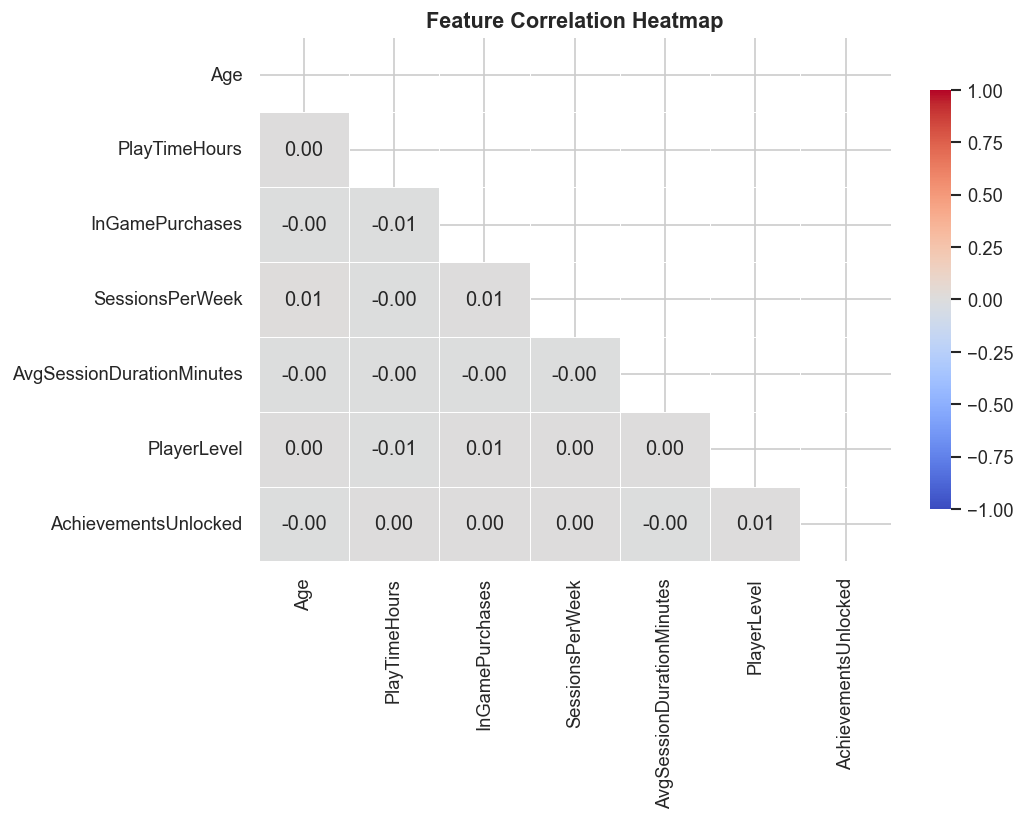

In [6]:
# Correlation heatmap (numeric features only)
num_cols = ['Age','PlayTimeHours','InGamePurchases','SessionsPerWeek',
            'AvgSessionDurationMinutes','PlayerLevel','AchievementsUnlocked']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={'shrink':0.8})
plt.title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 3️⃣ Preprocessing

In [7]:
df_proc = df.copy()

# Drop ID — not a feature
df_proc.drop('PlayerID', axis=1, inplace=True)

# Encode target with explicit order
df_proc['EngagementLevel'] = df_proc['EngagementLevel'].map({'Low':0,'Medium':1,'High':2})

# One-Hot encode categoricals
cat_cols = ['Gender','Location','GameGenre','GameDifficulty']
df_proc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True)

X = df_proc.drop('EngagementLevel', axis=1)
y = df_proc['EngagementLevel']

print(f'Total features after encoding : {X.shape[1]}')
print(f'Feature names: {X.columns.tolist()}')

Total features after encoding : 17
Feature names: ['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'Gender_Male', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'GameDifficulty_Hard', 'GameDifficulty_Medium']


In [8]:
# ✅ Split FIRST → then Scale (no data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

# Non-negative version needed for Chi2
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X_train_mm = pd.DataFrame(mms.fit_transform(X_train), columns=X.columns)
X_test_mm  = pd.DataFrame(mms.transform(X_test),      columns=X.columns)

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')
print(f'Class balance (train):\n{pd.Series(y_train).value_counts().sort_index().rename({0:"Low",1:"Medium",2:"High"})}')

Train: (32027, 17) | Test: (8007, 17)
Class balance (train):
EngagementLevel
Low        8259
Medium    15499
High       8269
Name: count, dtype: int64


---
## 4️⃣ Feature Selection

> Feature Selection keeps a **subset of the original features** — no transformation.

| Method | Idea | Algorithm used here |
|--------|------|---------------------|
| **Filter** | Statistical score, model-independent | Chi² + ANOVA F-test |
| **Wrapper** | Uses a model to score subsets | RFE with Random Forest |
| **Embedded** | Selection happens during training | Lasso (L1) + RF Importance |

### 4A — Filter Method: Chi² + ANOVA F-test

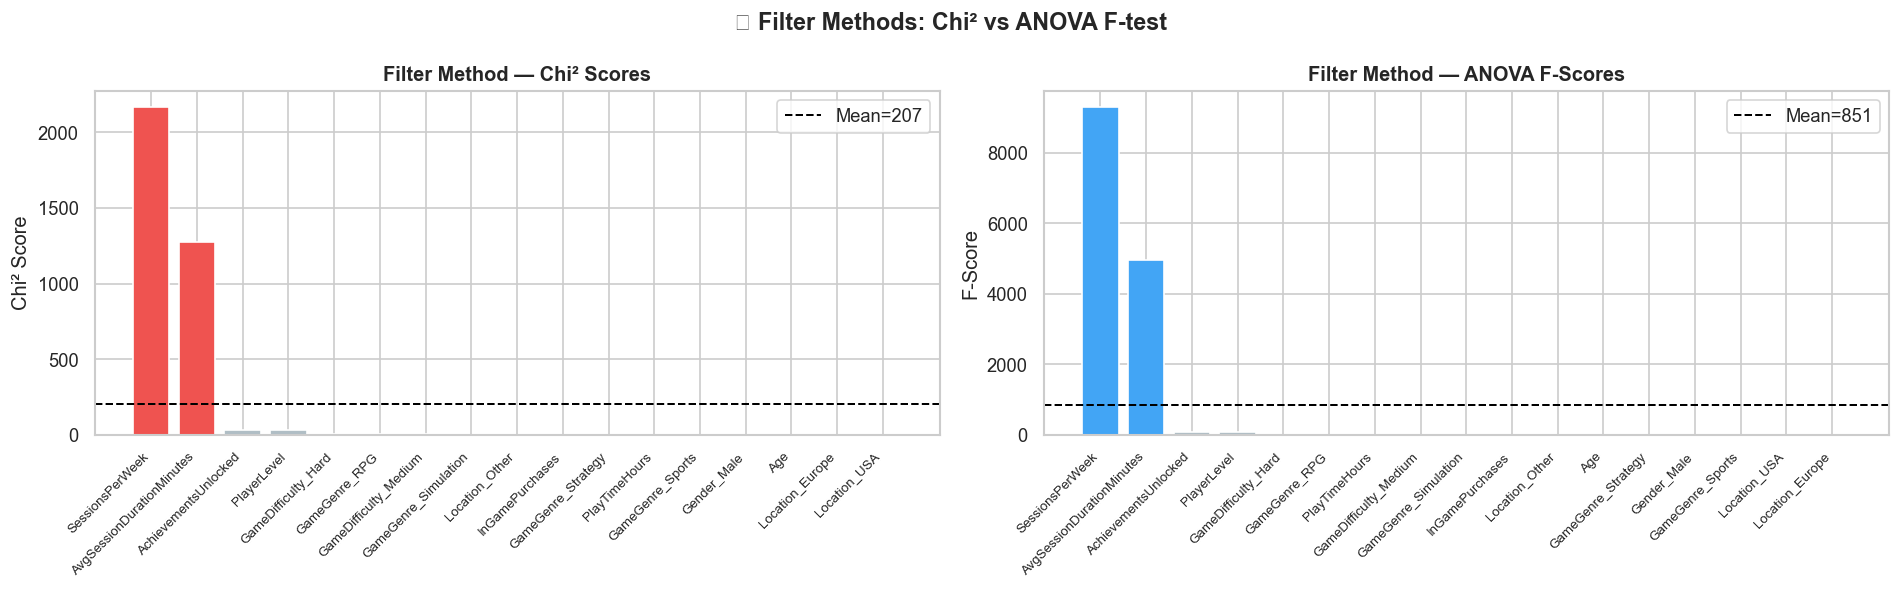

Chi²  selected  : 2  features
ANOVA selected  : 2 features
Filter agreed   : 2 features → ['AvgSessionDurationMinutes', 'SessionsPerWeek']


In [9]:
# --- Chi-Squared (needs non-negative values → MinMax scaled) ---
chi2_sel = SelectKBest(score_func=chi2, k='all')
chi2_sel.fit(X_train_mm, y_train)
chi2_scores = pd.Series(chi2_sel.scores_, index=X.columns).sort_values(ascending=False)

# --- ANOVA F-test ---
anova_sel = SelectKBest(score_func=f_classif, k='all')
anova_sel.fit(X_train_sc, y_train)
anova_scores = pd.Series(anova_sel.scores_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chi2
c_mean = chi2_scores.mean()
colors_chi = ['#ef5350' if v > c_mean else '#b0bec5' for v in chi2_scores]
axes[0].bar(range(len(chi2_scores)), chi2_scores.values, color=colors_chi, edgecolor='white')
axes[0].axhline(c_mean, linestyle='--', color='black', linewidth=1.2, label=f'Mean={c_mean:.0f}')
axes[0].set_xticks(range(len(chi2_scores)))
axes[0].set_xticklabels(chi2_scores.index, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Filter Method — Chi² Scores', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Chi² Score')
axes[0].legend()

# ANOVA
a_mean = anova_scores.mean()
colors_an = ['#42a5f5' if v > a_mean else '#b0bec5' for v in anova_scores]
axes[1].bar(range(len(anova_scores)), anova_scores.values, color=colors_an, edgecolor='white')
axes[1].axhline(a_mean, linestyle='--', color='black', linewidth=1.2, label=f'Mean={a_mean:.0f}')
axes[1].set_xticks(range(len(anova_scores)))
axes[1].set_xticklabels(anova_scores.index, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Filter Method — ANOVA F-Scores', fontweight='bold', fontsize=12)
axes[1].set_ylabel('F-Score')
axes[1].legend()

plt.suptitle('📊 Filter Methods: Chi² vs ANOVA F-test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_filter_methods.png', bbox_inches='tight')
plt.show()

# Select features above mean in both
selected_chi2  = set(chi2_scores[chi2_scores  > c_mean].index)
selected_anova = set(anova_scores[anova_scores > a_mean].index)
selected_filter = selected_chi2 & selected_anova   # intersection = agreed by both

print(f'Chi²  selected  : {len(selected_chi2)}  features')
print(f'ANOVA selected  : {len(selected_anova)} features')
print(f'Filter agreed   : {len(selected_filter)} features → {list(selected_filter)}')

### 4B — Wrapper Method: RFE (Recursive Feature Elimination)

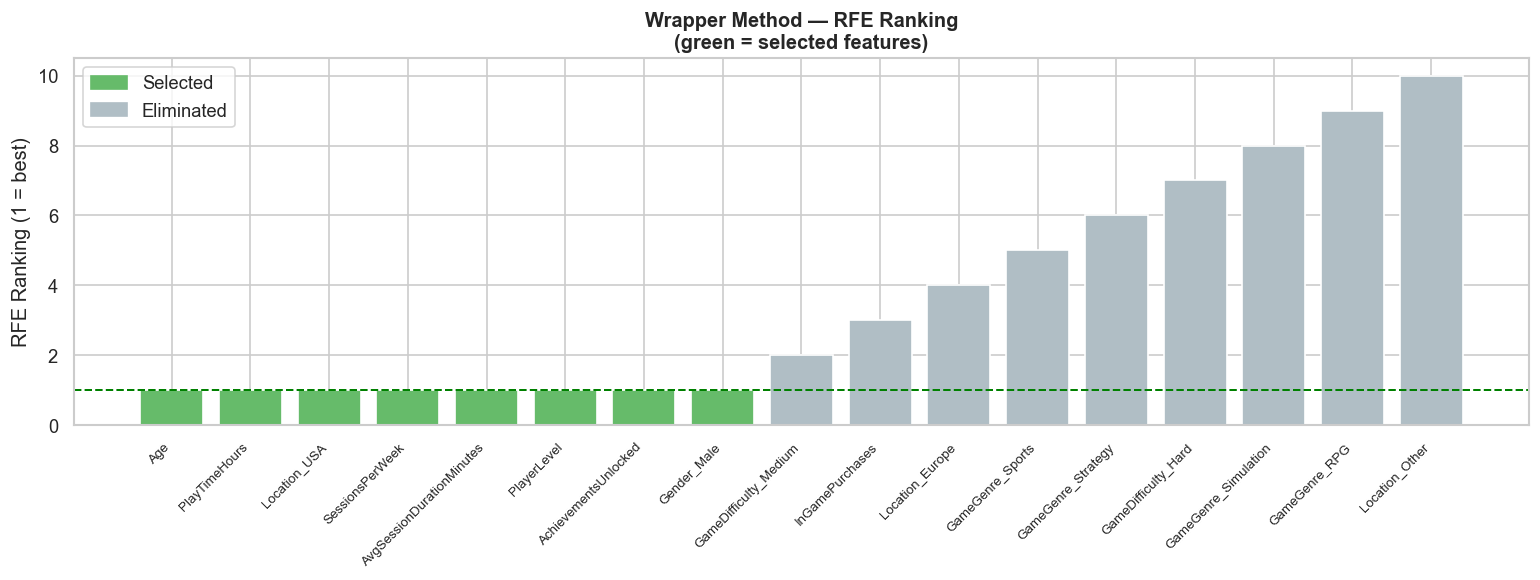

✅ RFE selected 8 features:
['Location_USA', 'SessionsPerWeek', 'AchievementsUnlocked', 'Gender_Male', 'PlayerLevel', 'AvgSessionDurationMinutes', 'PlayTimeHours', 'Age']


In [10]:
rf_rfe = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rfe = RFE(estimator=rf_rfe, n_features_to_select=8, step=1)
rfe.fit(X_train_sc, y_train)

rfe_df = pd.DataFrame({
    'Feature' : X.columns,
    'Ranking' : rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('Ranking')

plt.figure(figsize=(13, 5))
colors_rfe = ['#66bb6a' if s else '#b0bec5' for s in rfe_df['Selected']]
plt.bar(rfe_df['Feature'], rfe_df['Ranking'], color=colors_rfe, edgecolor='white')
plt.axhline(1, linestyle='--', color='green', linewidth=1.2, label='Rank 1 = Selected')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('RFE Ranking (1 = best)')
plt.title('Wrapper Method — RFE Ranking\n(green = selected features)', fontweight='bold', fontsize=12)
plt.legend()
green_patch = mpatches.Patch(color='#66bb6a', label='Selected')
grey_patch  = mpatches.Patch(color='#b0bec5', label='Eliminated')
plt.legend(handles=[green_patch, grey_patch])
plt.tight_layout()
plt.savefig('04_wrapper_rfe.png', bbox_inches='tight')
plt.show()

selected_rfe = set(X.columns[rfe.support_])
print(f'✅ RFE selected {len(selected_rfe)} features:')
print(list(selected_rfe))

### 4C — Embedded Method: Lasso (L1) + Random Forest Importance

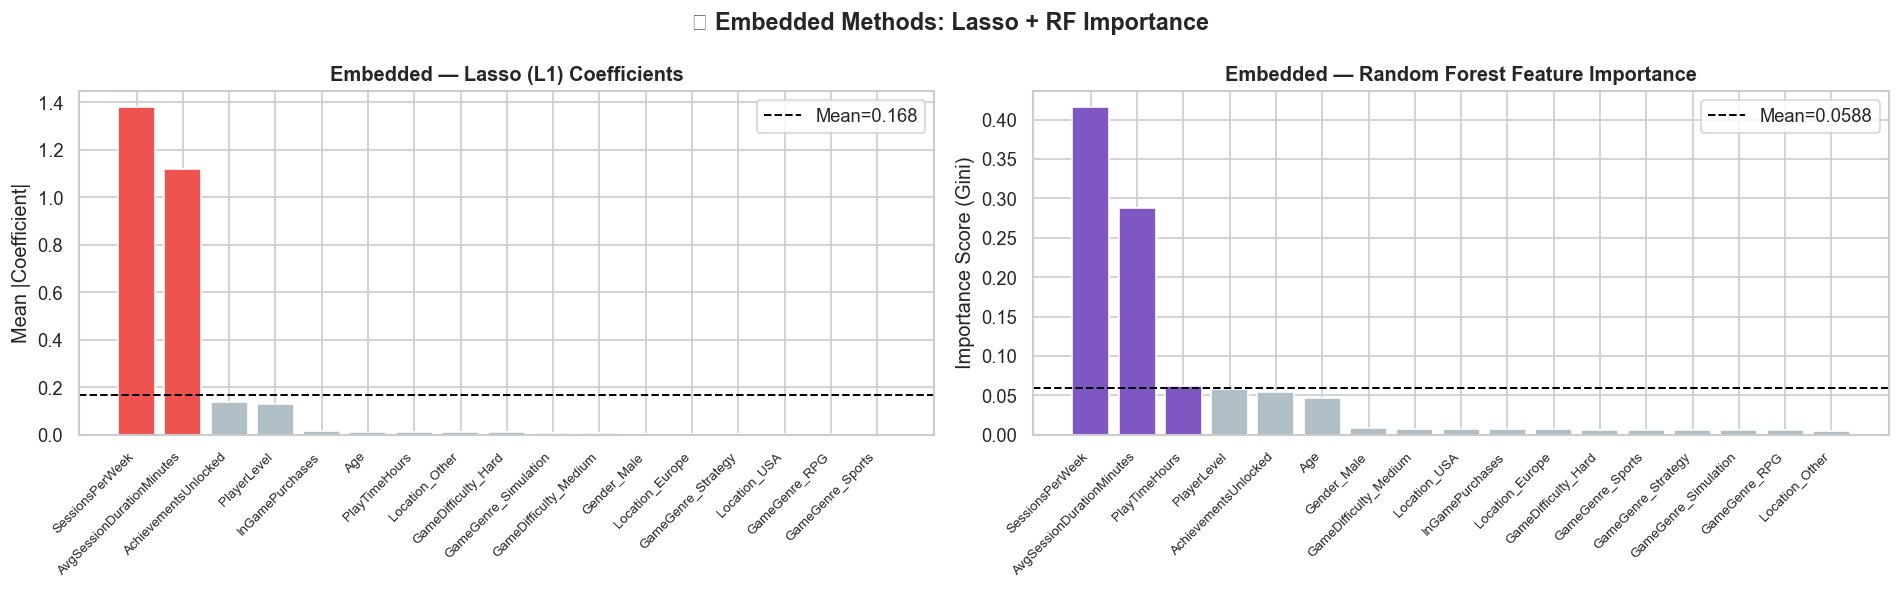

Lasso selected  : 2  → ['AvgSessionDurationMinutes', 'SessionsPerWeek']
RF    selected  : 3  → ['AvgSessionDurationMinutes', 'PlayTimeHours', 'SessionsPerWeek']
Embedded agreed : 2 → ['AvgSessionDurationMinutes', 'SessionsPerWeek']


In [11]:
# ── Lasso / L1 Regularization ──────────────────────────────
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.5,
                            max_iter=2000, random_state=RANDOM_STATE)
lasso.fit(X_train_sc, y_train)

# Mean absolute coefficient across all classes
lasso_importance = pd.Series(
    np.abs(lasso.coef_).mean(axis=0), index=X.columns
).sort_values(ascending=False)

# ── Random Forest Feature Importance ───────────────────────
rf_emb = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_emb.fit(X_train_sc, y_train)
rf_importance = pd.Series(rf_emb.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Lasso
lmean = lasso_importance.mean()
axes[0].bar(range(len(lasso_importance)), lasso_importance.values,
            color=['#ef5350' if v > lmean else '#b0bec5' for v in lasso_importance],
            edgecolor='white')
axes[0].axhline(lmean, linestyle='--', color='black', linewidth=1.2, label=f'Mean={lmean:.3f}')
axes[0].set_xticks(range(len(lasso_importance)))
axes[0].set_xticklabels(lasso_importance.index, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Embedded — Lasso (L1) Coefficients', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Mean |Coefficient|')
axes[0].legend()

# RF Importance
rfmean = rf_importance.mean()
axes[1].bar(range(len(rf_importance)), rf_importance.values,
            color=['#7e57c2' if v > rfmean else '#b0bec5' for v in rf_importance],
            edgecolor='white')
axes[1].axhline(rfmean, linestyle='--', color='black', linewidth=1.2, label=f'Mean={rfmean:.4f}')
axes[1].set_xticks(range(len(rf_importance)))
axes[1].set_xticklabels(rf_importance.index, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Embedded — Random Forest Feature Importance', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Importance Score (Gini)')
axes[1].legend()

plt.suptitle('🔧 Embedded Methods: Lasso + RF Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_embedded_methods.png', bbox_inches='tight')
plt.show()

selected_lasso = set(lasso_importance[lasso_importance > lmean].index)
selected_rf    = set(rf_importance[rf_importance > rfmean].index)
selected_embedded = selected_lasso & selected_rf

print(f'Lasso selected  : {len(selected_lasso)}  → {list(selected_lasso)}')
print(f'RF    selected  : {len(selected_rf)}  → {list(selected_rf)}')
print(f'Embedded agreed : {len(selected_embedded)} → {list(selected_embedded)}')

### 4D — Feature Selection Summary & Consensus

In [12]:
# Score each feature: how many methods selected it? (max=3)
all_features = list(X.columns)
vote_df = pd.DataFrame({'Feature': all_features})
vote_df['Filter']   = vote_df['Feature'].isin(selected_filter).astype(int)
vote_df['Wrapper']  = vote_df['Feature'].isin(selected_rfe).astype(int)
vote_df['Embedded'] = vote_df['Feature'].isin(selected_embedded).astype(int)
vote_df['Votes']    = vote_df[['Filter','Wrapper','Embedded']].sum(axis=1)
vote_df = vote_df.sort_values('Votes', ascending=False)

print('=== Feature Selection Consensus ===')
print(vote_df.to_string(index=False))

# Final: features selected by at least 2 methods
final_features = vote_df[vote_df['Votes'] >= 2]['Feature'].tolist()
print(f'\n✅ Final selected features (≥2 votes): {len(final_features)}')
print(final_features)

=== Feature Selection Consensus ===
                  Feature  Filter  Wrapper  Embedded  Votes
          SessionsPerWeek       1        1         1      3
AvgSessionDurationMinutes       1        1         1      3
                      Age       0        1         0      1
              PlayerLevel       0        1         0      1
     AchievementsUnlocked       0        1         0      1
              Gender_Male       0        1         0      1
            PlayTimeHours       0        1         0      1
             Location_USA       0        1         0      1
     GameGenre_Simulation       0        0         0      0
      GameDifficulty_Hard       0        0         0      0
       GameGenre_Strategy       0        0         0      0
         GameGenre_Sports       0        0         0      0
          Location_Europe       0        0         0      0
            GameGenre_RPG       0        0         0      0
           Location_Other       0        0         0      0
    

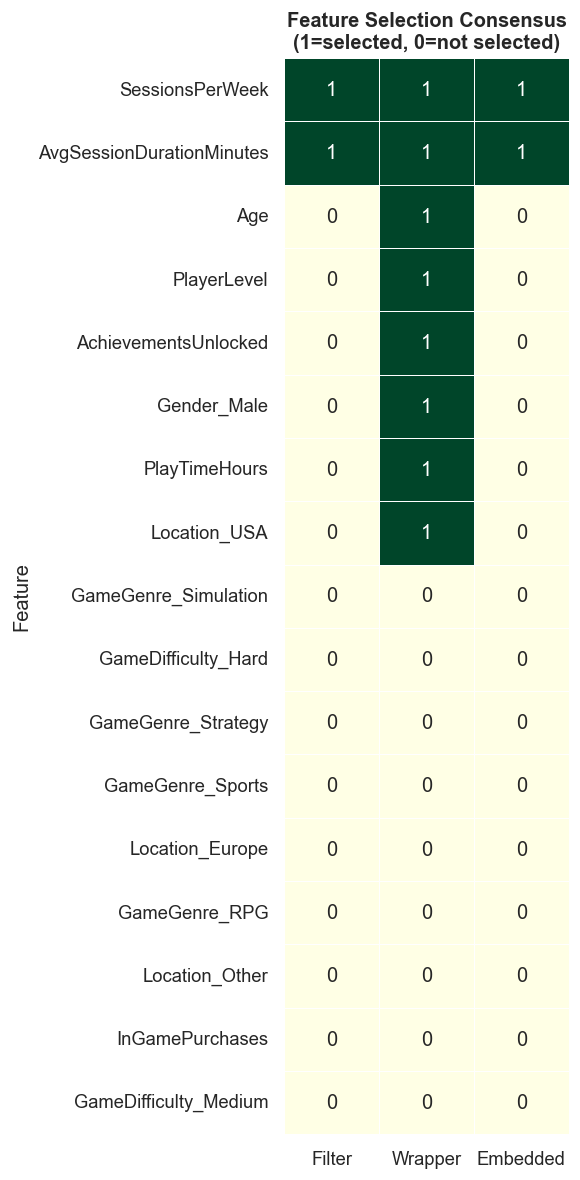

In [13]:
# Heatmap: which method selected which feature
hm_data = vote_df.set_index('Feature')[['Filter','Wrapper','Embedded']]

plt.figure(figsize=(5, 10))
sns.heatmap(hm_data, annot=True, fmt='d', cmap='YlGn',
            linewidths=0.5, cbar=False,
            xticklabels=['Filter','Wrapper','Embedded'])
plt.title('Feature Selection Consensus\n(1=selected, 0=not selected)', fontweight='bold')
plt.tight_layout()
plt.savefig('06_selection_consensus.png', bbox_inches='tight')
plt.show()

In [14]:
# Apply final feature selection
X_train_sel = X_train_sc[final_features]
X_test_sel  = X_test_sc[final_features]
print(f'Shape after Feature Selection: Train={X_train_sel.shape}, Test={X_test_sel.shape}')

Shape after Feature Selection: Train=(32027, 2), Test=(8007, 2)


---
## 5️⃣ Feature Extraction

> Feature Extraction **creates new components** by transforming the original features.

| Method | Type | Idea |
|--------|------|------|
| **PCA** | Unsupervised | Maximizes variance in new axes |
| **LDA** | Supervised | Maximizes class separability |

### 5A — PCA (Principal Component Analysis)

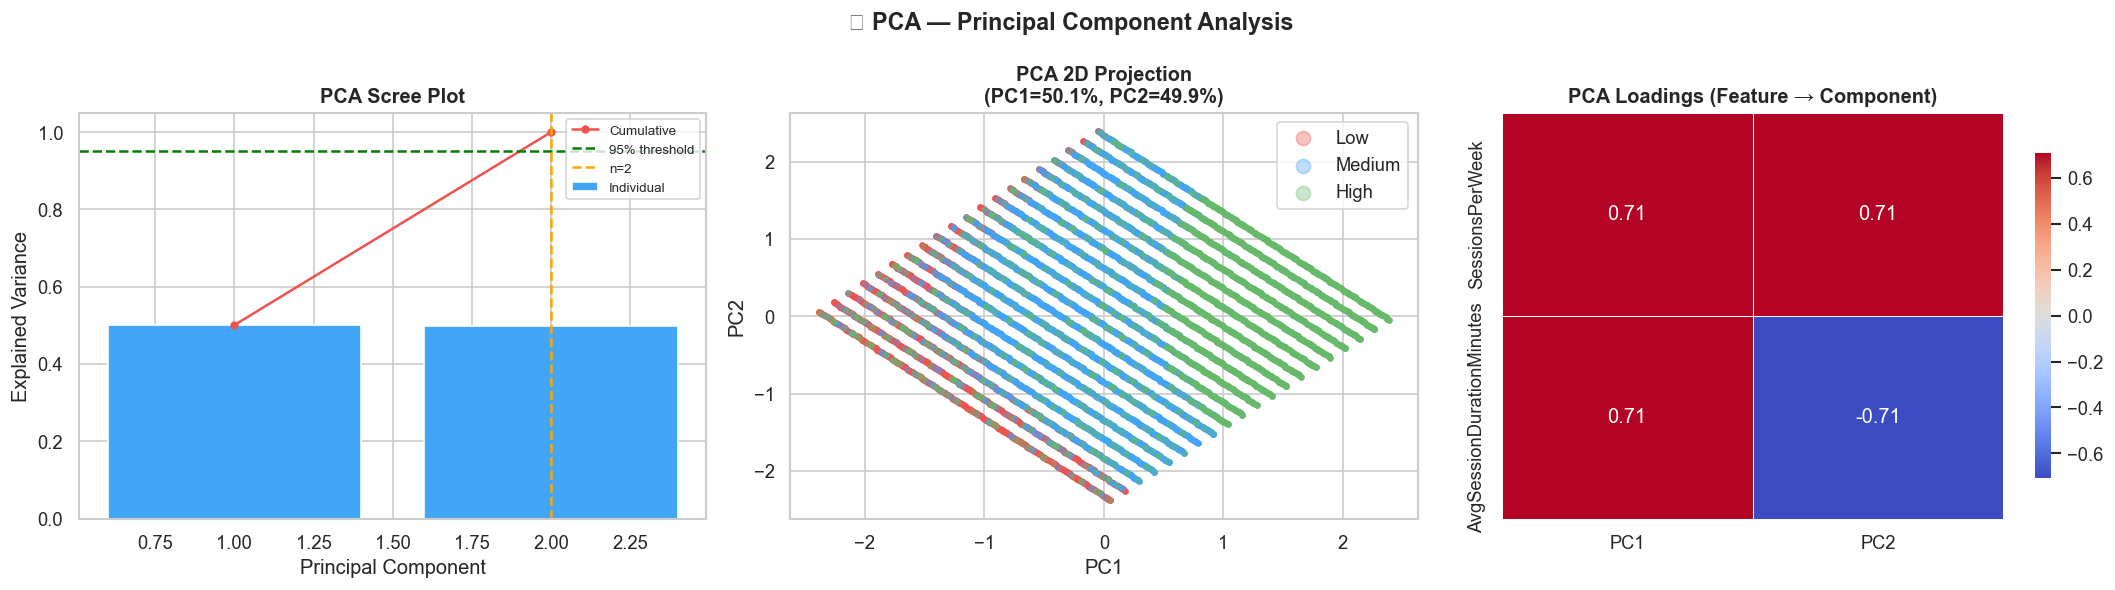

✅ 2 PCA components retain 95% of variance


In [15]:
# Find optimal number of components
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_sel)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_pca = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='#42a5f5', edgecolor='white', label='Individual')
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#ef5350', markersize=4, label='Cumulative')
axes[0].axhline(0.95, linestyle='--', color='green', linewidth=1.5, label='95% threshold')
axes[0].axvline(n_pca, linestyle='--', color='orange', linewidth=1.5, label=f'n={n_pca}')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance')
axes[0].set_title('PCA Scree Plot', fontweight='bold')
axes[0].legend(fontsize=8)

# 2D scatter
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_train_sel)
cmap = {0:'#ef5350',1:'#42a5f5',2:'#66bb6a'}
lmap = {0:'Low',1:'Medium',2:'High'}
for cls in [0,1,2]:
    m = y_train==cls
    axes[1].scatter(X_2d[m,0], X_2d[m,1], c=cmap[cls], label=lmap[cls], alpha=0.35, s=8)
axes[1].set_title(f'PCA 2D Projection\n(PC1={pca_2d.explained_variance_ratio_[0]:.1%}, PC2={pca_2d.explained_variance_ratio_[1]:.1%})',
                  fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3)

# PCA loadings heatmap
pca_k = PCA(n_components=min(6, len(final_features)), random_state=RANDOM_STATE)
pca_k.fit(X_train_sel)
loadings = pd.DataFrame(pca_k.components_.T, index=final_features,
                         columns=[f'PC{i+1}' for i in range(pca_k.n_components_)])
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=axes[2], cbar_kws={'shrink':0.8})
axes[2].set_title('PCA Loadings (Feature → Component)', fontweight='bold')

plt.suptitle('📐 PCA — Principal Component Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_pca_analysis.png', bbox_inches='tight')
plt.show()
print(f'✅ {n_pca} PCA components retain 95% of variance')

In [16]:
pca = PCA(n_components=n_pca, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca  = pca.transform(X_test_sel)
print(f'PCA: {X_train_sel.shape[1]} features → {X_train_pca.shape[1]} components')
print(f'Variance retained: {pca.explained_variance_ratio_.sum():.2%}')

PCA: 2 features → 2 components
Variance retained: 100.00%


### 5B — LDA (Linear Discriminant Analysis)

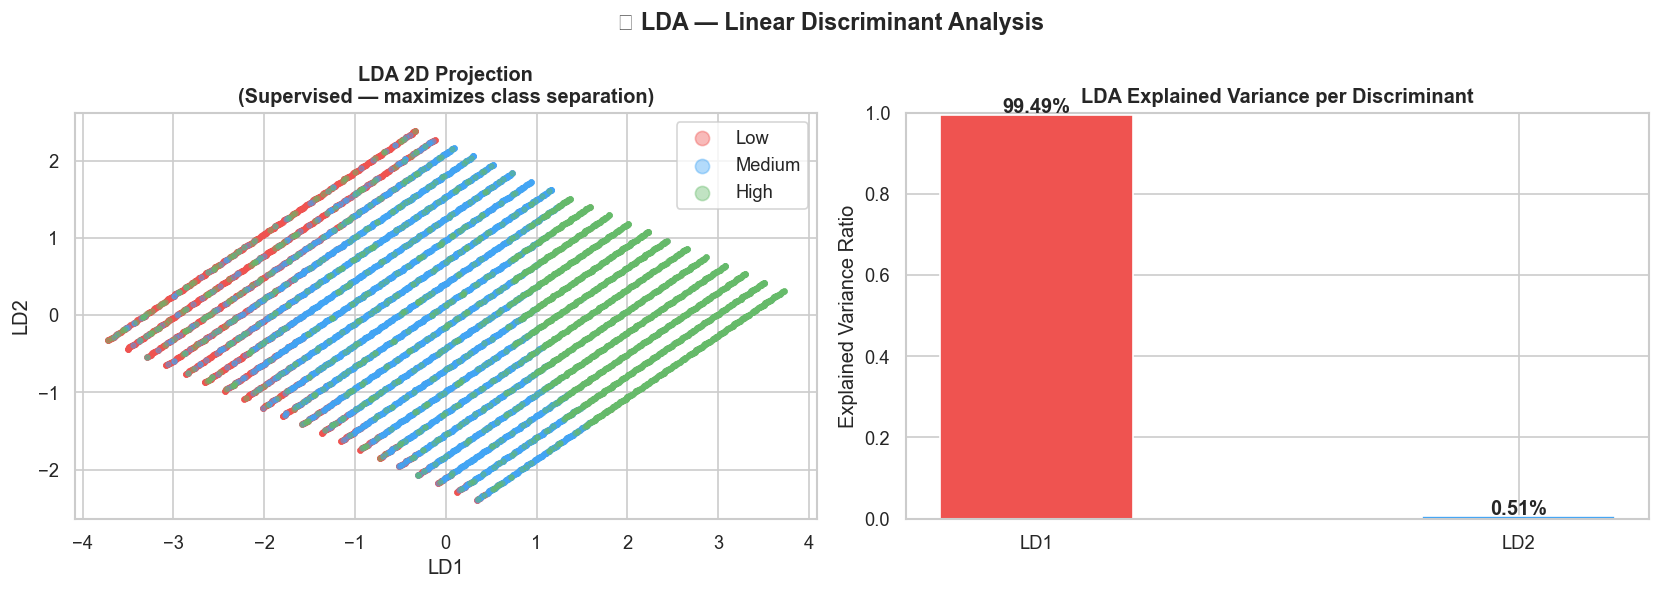

LDA: 2 features → 2 discriminants
Explained variance: LD1=99.49%, LD2=0.51%, Total=100.00%


In [17]:
# LDA max components = n_classes - 1 = 2
n_lda = 2  # 3 classes → max 2 discriminants

lda = LDA(n_components=n_lda)
X_train_lda = lda.fit_transform(X_train_sel, y_train)
X_test_lda  = lda.transform(X_test_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LDA 2D scatter
for cls in [0,1,2]:
    m = y_train==cls
    axes[0].scatter(X_train_lda[m,0], X_train_lda[m,1],
                    c=cmap[cls], label=lmap[cls], alpha=0.4, s=8)
axes[0].set_title('LDA 2D Projection\n(Supervised — maximizes class separation)',
                  fontweight='bold')
axes[0].set_xlabel('LD1'); axes[0].set_ylabel('LD2')
axes[0].legend(markerscale=3)

# Explained variance ratio (LDA)
lda_var = lda.explained_variance_ratio_
axes[1].bar([f'LD{i+1}' for i in range(len(lda_var))], lda_var,
            color=['#ef5350','#42a5f5'], edgecolor='white', width=0.4)
for i, v in enumerate(lda_var):
    axes[1].text(i, v+0.005, f'{v:.2%}', ha='center', fontweight='bold')
axes[1].set_title('LDA Explained Variance per Discriminant', fontweight='bold')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_ylim(0, 1)

plt.suptitle('🎯 LDA — Linear Discriminant Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_lda_analysis.png', bbox_inches='tight')
plt.show()
print(f'LDA: {X_train_sel.shape[1]} features → {X_train_lda.shape[1]} discriminants')
print(f'Explained variance: LD1={lda_var[0]:.2%}, LD2={lda_var[1]:.2%}, Total={sum(lda_var):.2%}')

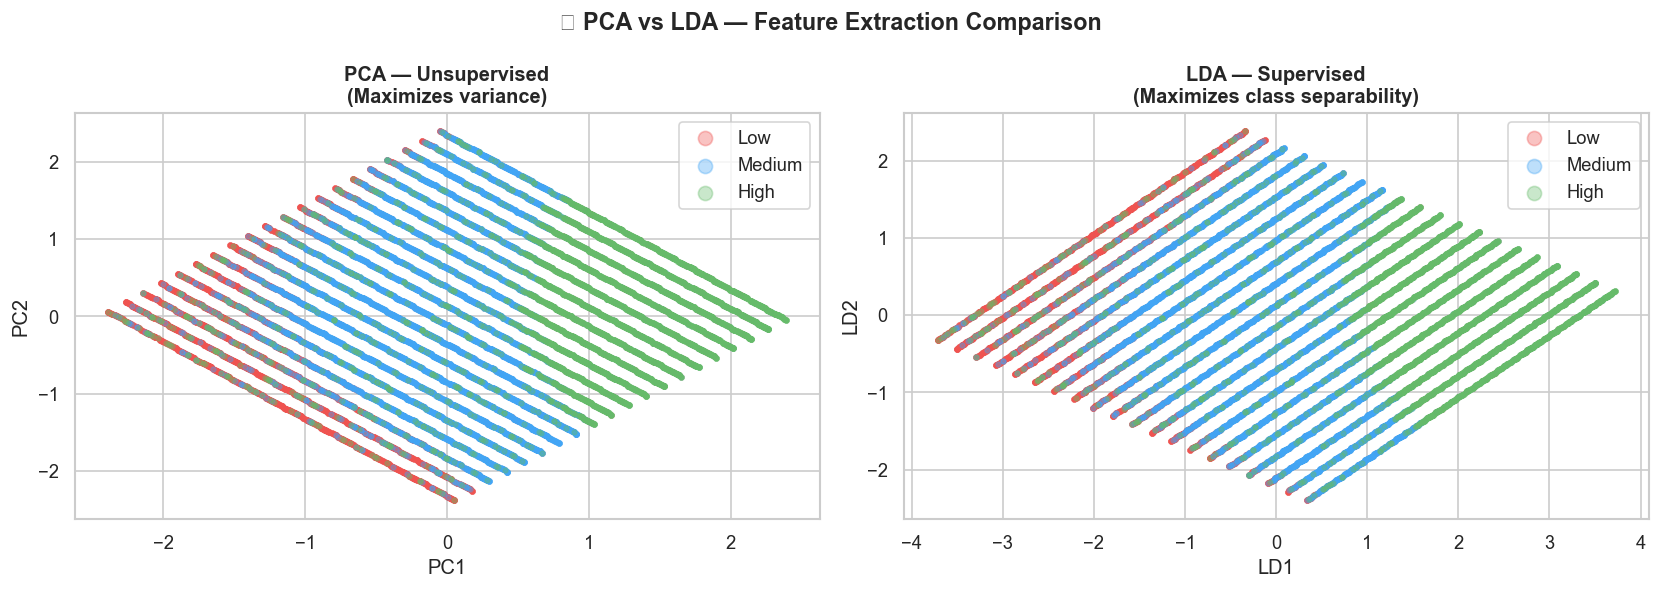

In [18]:
# PCA vs LDA side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in [0,1,2]:
    m = y_train==cls
    axes[0].scatter(X_2d[m,0], X_2d[m,1], c=cmap[cls], label=lmap[cls], alpha=0.35, s=8)
    axes[1].scatter(X_train_lda[m,0], X_train_lda[m,1], c=cmap[cls], label=lmap[cls], alpha=0.35, s=8)

axes[0].set_title('PCA — Unsupervised\n(Maximizes variance)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

axes[1].set_title('LDA — Supervised\n(Maximizes class separability)', fontweight='bold')
axes[1].set_xlabel('LD1'); axes[1].set_ylabel('LD2')
axes[1].legend(markerscale=3)

plt.suptitle('📊 PCA vs LDA — Feature Extraction Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_pca_vs_lda.png', bbox_inches='tight')
plt.show()

---
## 6️⃣ Model Training

We train each model on **3 versions** of the data:
- `sel` — After Feature Selection only
- `pca` — After Feature Selection + PCA
- `lda` — After Feature Selection + LDA

In [19]:
datasets = {
    'Selected Features' : (X_train_sel.values, X_test_sel.values),
    'PCA'               : (X_train_pca,         X_test_pca),
    'LDA'               : (X_train_lda,          X_test_lda)
}

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15,
        min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM': SVC(
        kernel='rbf', C=10, gamma='scale',
        random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1)
}

all_results = {}

for ds_name, (Xtr, Xte) in datasets.items():
    print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  Dataset: {ds_name} (shape: {Xtr.shape})')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    all_results[ds_name] = {}
    for m_name, model in models.items():
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)
        acc = accuracy_score(y_test, y_pred)
        cv  = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy', n_jobs=-1)
        all_results[ds_name][m_name] = {
            'model':m_name,'y_pred':y_pred,
            'accuracy':acc,'cv_mean':cv.mean(),'cv_std':cv.std()
        }
        print(f'  {m_name:<16} Test={acc:.4f}  CV={cv.mean():.4f}±{cv.std():.4f}')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset: Selected Features (shape: (32027, 2))
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Random Forest    Test=0.8841  CV=0.8793±0.0041
  SVM              Test=0.8850  CV=0.8823±0.0038
  KNN              Test=0.8819  CV=0.8764±0.0046

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset: PCA (shape: (32027, 2))
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Random Forest    Test=0.8846  CV=0.8801±0.0047
  SVM              Test=0.8850  CV=0.8823±0.0038
  KNN              Test=0.8804  CV=0.8764±0.0048

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset: LDA (shape: (32027, 2))
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Random Forest    Test=0.8850  CV=0.8799±0.0042
  SVM              Test=0.8845  CV=0.8830±0.0031
  KNN              Test=0.8800  CV=0.8761±0.0041


---
## 7️⃣ Evaluation & Comparison

In [20]:
# Classification reports for best setup (LDA is usually best for multi-class)
class_names = ['Low','Medium','High']
for ds_name, mods in all_results.items():
    print(f'\n======  {ds_name}  ======')
    for m_name, res in mods.items():
        print(f'\n--- {m_name} ---')
        print(classification_report(y_test, res['y_pred'], target_names=class_names))


======  Selected Features  ======

--- Random Forest ---
              precision    recall  f1-score   support

         Low       0.85      0.85      0.85      2065
      Medium       0.88      0.91      0.90      3875
        High       0.92      0.87      0.89      2067

    accuracy                           0.88      8007
   macro avg       0.88      0.88      0.88      8007
weighted avg       0.88      0.88      0.88      8007


--- SVM ---
              precision    recall  f1-score   support

         Low       0.87      0.84      0.85      2065
      Medium       0.88      0.92      0.90      3875
        High       0.92      0.87      0.89      2067

    accuracy                           0.88      8007
   macro avg       0.89      0.87      0.88      8007
weighted avg       0.89      0.88      0.88      8007


--- KNN ---
              precision    recall  f1-score   support

         Low       0.84      0.85      0.85      2065
      Medium       0.88      0.90      0.89  

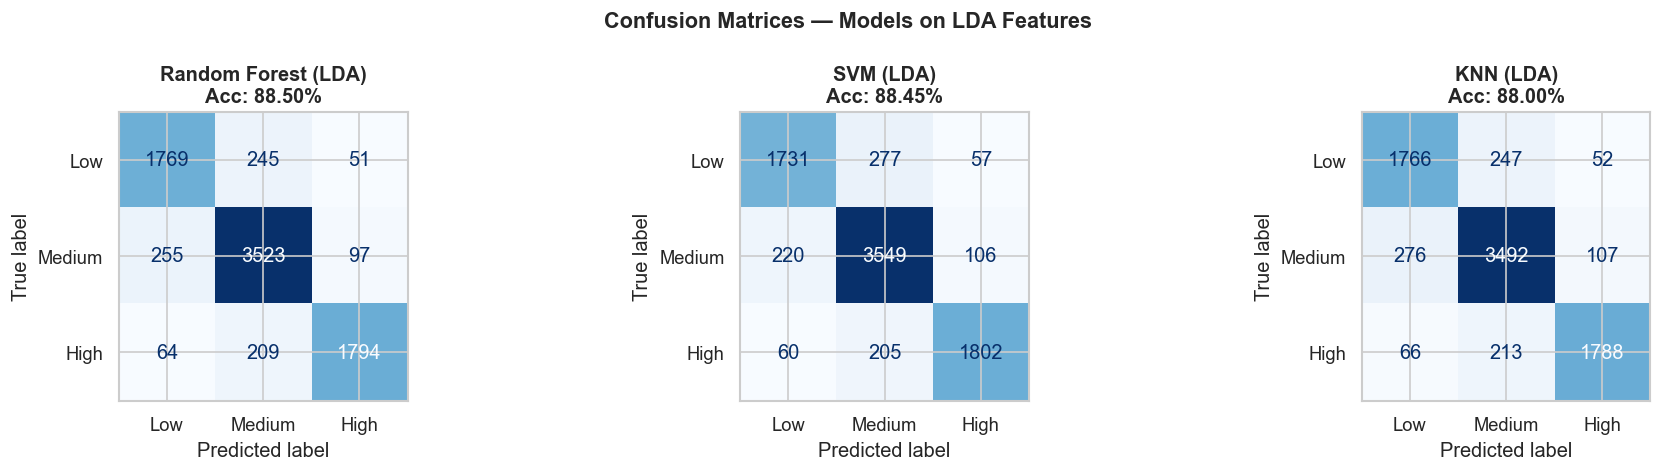

In [21]:
# Confusion matrices — best dataset per model
# Show LDA results (typically best class separation)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (m_name, res) in zip(axes, all_results['LDA'].items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{m_name} (LDA)\nAcc: {res["accuracy"]:.2%}', fontweight='bold')

plt.suptitle('Confusion Matrices — Models on LDA Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('10_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [22]:
# Full comparison table
rows = []
for ds_name, mods in all_results.items():
    for m_name, res in mods.items():
        rows.append({
            'Features'    : ds_name,
            'Model'       : m_name,
            'Test Acc'    : res['accuracy'],
            'CV Mean'     : res['cv_mean'],
            'CV Std'      : res['cv_std']
        })

results_df = pd.DataFrame(rows).sort_values('Test Acc', ascending=False).reset_index(drop=True)
results_df['Test Acc'] = results_df['Test Acc'].map('{:.2%}'.format)
results_df['CV Mean']  = results_df['CV Mean'].map('{:.2%}'.format)
results_df['CV Std']   = results_df['CV Std'].map('{:.4f}'.format)
print('=== FULL RESULTS TABLE ===')
print(results_df.to_string(index=False))

=== FULL RESULTS TABLE ===
         Features         Model Test Acc CV Mean CV Std
Selected Features           SVM   88.50%  88.23% 0.0038
              PCA           SVM   88.50%  88.23% 0.0038
              LDA Random Forest   88.50%  87.99% 0.0042
              PCA Random Forest   88.46%  88.01% 0.0047
              LDA           SVM   88.45%  88.30% 0.0031
Selected Features Random Forest   88.41%  87.93% 0.0041
Selected Features           KNN   88.19%  87.64% 0.0046
              PCA           KNN   88.04%  87.64% 0.0048
              LDA           KNN   88.00%  87.61% 0.0041


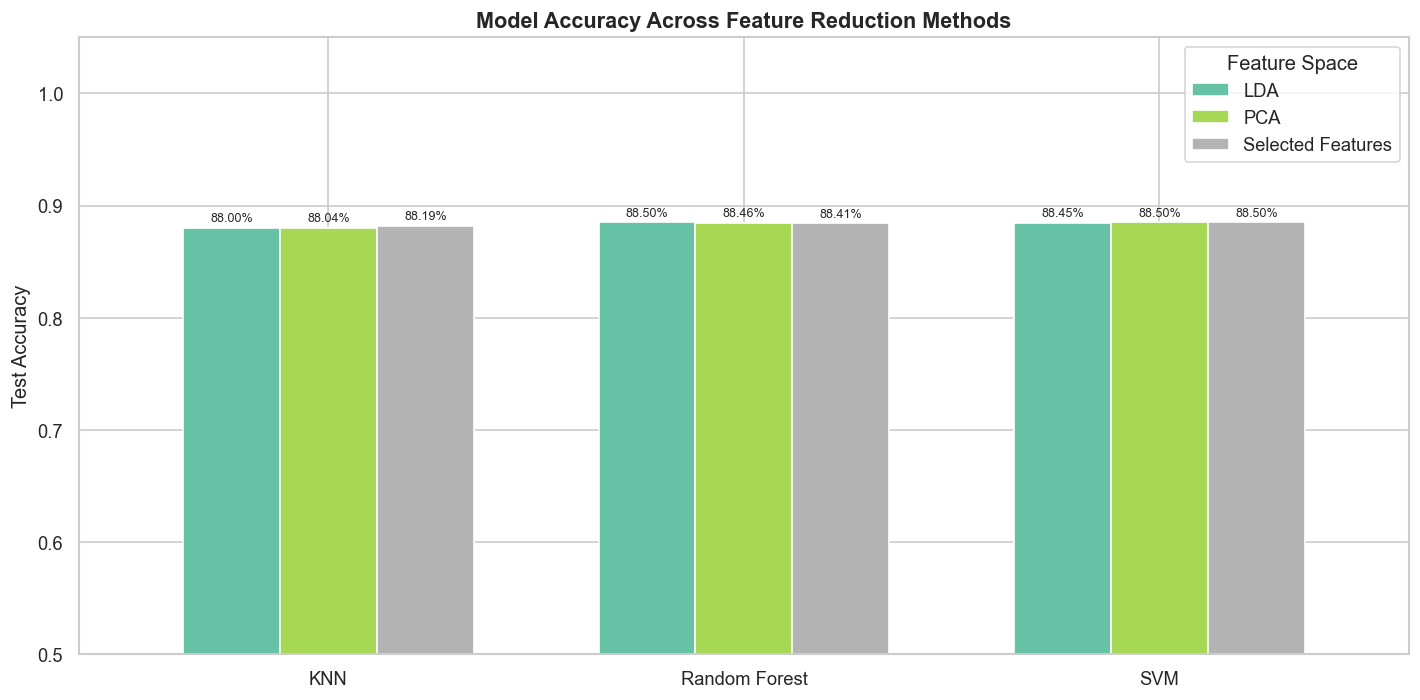

In [23]:
# Grouped bar chart — all models × all datasets
rows_num = []
for ds_name, mods in all_results.items():
    for m_name, res in mods.items():
        rows_num.append({'Features':ds_name,'Model':m_name,'Accuracy':res['accuracy']})

pivot = pd.DataFrame(rows_num).pivot(index='Model', columns='Features', values='Accuracy')

ax = pivot.plot(kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('Model Accuracy Across Feature Reduction Methods', fontweight='bold', fontsize=13)
ax.set_ylabel('Test Accuracy')
ax.set_xlabel('')
ax.set_ylim(0.5, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.legend(title='Feature Space', bbox_to_anchor=(1,1))

for container in ax.containers:
    ax.bar_label(container, fmt='{:.2%}', fontsize=7.5, padding=2)

plt.tight_layout()
plt.savefig('11_full_comparison.png', bbox_inches='tight')
plt.show()

---
## 8️⃣ Dimension Reduction Summary

In [24]:
print('=' * 60)
print('         DIMENSION REDUCTION PIPELINE SUMMARY')
print('=' * 60)
print(f'  Step 0 — Original features         : {X.shape[1]}')
print(f'  Step 1 — After Feature Selection   : {len(final_features)}')
print(f'            Filter (Chi2 ∩ ANOVA)    : {len(selected_filter)}')
print(f'            Wrapper (RFE)             : {len(selected_rfe)}')
print(f'            Embedded (Lasso ∩ RF)     : {len(selected_embedded)}')
print(f'            Final (≥2 votes)          : {len(final_features)}')
print(f'  Step 2A— After PCA (95% var)        : {X_train_pca.shape[1]} components')
print(f'  Step 2B— After LDA                  : {X_train_lda.shape[1]} discriminants')
print('=' * 60)

rows_num2 = []
for ds_name, mods in all_results.items():
    for m_name, res in mods.items():
        rows_num2.append({'Features':ds_name,'Model':m_name,'Accuracy':res['accuracy']})
best = pd.DataFrame(rows_num2).sort_values('Accuracy', ascending=False).iloc[0]
print(f'\n  🏆 Best Result:')
print(f'     Model    : {best["Model"]}')
print(f'     Features : {best["Features"]}')
print(f'     Accuracy : {best["Accuracy"]:.2%}')
print('=' * 60)

         DIMENSION REDUCTION PIPELINE SUMMARY
  Step 0 — Original features         : 17
  Step 1 — After Feature Selection   : 2
            Filter (Chi2 ∩ ANOVA)    : 2
            Wrapper (RFE)             : 8
            Embedded (Lasso ∩ RF)     : 2
            Final (≥2 votes)          : 2
  Step 2A— After PCA (95% var)        : 2 components
  Step 2B— After LDA                  : 2 discriminants

  🏆 Best Result:
     Model    : SVM
     Features : Selected Features
     Accuracy : 88.50%


---
## 9️⃣ Save Models & Artifacts (For Streamlit GUI)

In [25]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

# ── Save Scalers ─────────────────────────────────────────
joblib.dump(scaler,  'saved_models/scaler.pkl')
joblib.dump(mms,     'saved_models/minmax_scaler.pkl')

# ── Save Feature Extractors ───────────────────────────────
joblib.dump(pca,     'saved_models/pca.pkl')
joblib.dump(lda,     'saved_models/lda.pkl')

# ── Save Final Feature List ───────────────────────────────
joblib.dump(final_features, 'saved_models/final_features.pkl')
joblib.dump(list(X.columns), 'saved_models/all_columns.pkl')

# ── Save All Trained Models ───────────────────────────────
for ds_name, mods in all_results.items():
    safe_ds = ds_name.replace(' ', '_')
    for m_name, res in mods.items():
        safe_m = m_name.replace(' ', '_')
        mdl_obj = models[m_name]  # already trained
        path = f'saved_models/{safe_ds}_{safe_m}.pkl'
        joblib.dump(mdl_obj, path)
        print(f'  ✅ Saved: {path}')

print('\n✅ All models and artifacts saved to saved_models/')

  ✅ Saved: saved_models/Selected_Features_Random_Forest.pkl
  ✅ Saved: saved_models/Selected_Features_SVM.pkl
  ✅ Saved: saved_models/Selected_Features_KNN.pkl
  ✅ Saved: saved_models/PCA_Random_Forest.pkl
  ✅ Saved: saved_models/PCA_SVM.pkl
  ✅ Saved: saved_models/PCA_KNN.pkl
  ✅ Saved: saved_models/LDA_Random_Forest.pkl
  ✅ Saved: saved_models/LDA_SVM.pkl
  ✅ Saved: saved_models/LDA_KNN.pkl

✅ All models and artifacts saved to saved_models/


In [26]:
# Verify saved files
files = os.listdir('saved_models')
print(f'Total files saved: {len(files)}')
for f in sorted(files):
    size = os.path.getsize(f'saved_models/{f}') / 1024
    print(f'  📦 {f:<45} {size:>8.1f} KB')

Total files saved: 15
  📦 LDA_KNN.pkl                                     1630.6 KB
  📦 LDA_Random_Forest.pkl                          40421.2 KB
  📦 LDA_SVM.pkl                                      494.7 KB
  📦 PCA_KNN.pkl                                     1630.6 KB
  📦 PCA_Random_Forest.pkl                          40421.2 KB
  📦 PCA_SVM.pkl                                      494.7 KB
  📦 Selected_Features_KNN.pkl                       1630.6 KB
  📦 Selected_Features_Random_Forest.pkl            40421.2 KB
  📦 Selected_Features_SVM.pkl                        494.7 KB
  📦 all_columns.pkl                                    0.3 KB
  📦 final_features.pkl                                 0.1 KB
  📦 lda.pkl                                            1.6 KB
  📦 minmax_scaler.pkl                                  2.0 KB
  📦 pca.pkl                                            1.4 KB
  📦 scaler.pkl                                         1.6 KB


In [ ]:
sample_player = {
    'Age': 25,
    'PlayTimeHours': 8.5,
    'InGamePurchases': 1,
    'SessionsPerWeek': 10,
    'AvgSessionDurationMinutes': 60,
    'PlayerLevel': 55,
    'AchievementsUnlocked': 40,
    'Gender': 'Male',
    'Location': 'USA',
    'GameGenre': 'Action',
    'GameDifficulty': 'Hard'
}

raw_df = pd.DataFrame([sample_player])
raw_enc = pd.get_dummies(raw_df, columns=['Gender','Location','GameGenre','GameDifficulty'], drop_first=True)

# Align columns
for col in X.columns:
    if col not in raw_enc.columns:
        raw_enc[col] = 0
raw_enc = raw_enc[X.columns]

# Scale & Select
raw_sc  = pd.DataFrame(scaler.transform(raw_enc), columns=X.columns)
raw_sel = raw_sc[final_features]

# Predict with all combos
label_map = {0:'Low', 1:'Medium', 2:'High'}
print('=== Sample Player Predictions ===')
print(f'Player: Age={sample_player["Age"]}, PlayTime={sample_player["PlayTimeHours"]}hrs, Level={sample_player["PlayerLevel"]}')
print()
for ds_name, (Xtr, Xte) in {
    'Selected Features': (X_train_sel.values, raw_sel.values),
    'PCA'              : (X_train_pca,         pca.transform(raw_sel)),
    'LDA'              : (X_train_lda,          lda.transform(raw_sel))
}.items():
    for m_name, mdl in models.items():
        pred = mdl.predict(Xte)[0]
        print(f'  [{ds_name:<20}] {m_name:<16} → {label_map[pred]}')

=== Sample Player Predictions ===
Player: Age=25, PlayTime=8.5hrs, Level=55

  [Selected Features   ] Random Forest    → Medium
  [Selected Features   ] SVM              → Medium
  [Selected Features   ] KNN              → Medium
  [PCA                 ] Random Forest    → Medium
  [PCA                 ] SVM              → Medium
  [PCA                 ] KNN              → Medium
  [LDA                 ] Random Forest    → Medium
  [LDA                 ] SVM              → Medium
  [LDA                 ] KNN              → Medium


---
## 1️⃣1️⃣ Streamlit App — Source Code

In [28]:
streamlit_code = '''
# ════════════════════════════════════════════════════
# app.py — Streamlit GUI for Gaming Behavior ML
# Run with: streamlit run app.py
# ════════════════════════════════════════════════════
# Pages:
#   🏠 Overview         — Pipeline summary & best results
#   📊 EDA              — Distributions & correlations
#   🔍 Feature Selection — Filter / Wrapper / Embedded + Consensus
#   📐 Feature Extraction — PCA / LDA / PCA vs LDA comparison
#   🤖 Model Results    — Accuracy, CV, Confusion Matrix, Report
#   🎯 Live Prediction  — Real-time player engagement prediction
# ════════════════════════════════════════════════════
# See full source code in app.py
'''
print(streamlit_code)


# ════════════════════════════════════════════════════
# app.py — Streamlit GUI for Gaming Behavior ML
# Run with: streamlit run app.py
# ════════════════════════════════════════════════════
# Pages:
#   🏠 Overview         — Pipeline summary & best results
#   📊 EDA              — Distributions & correlations
#   🔍 Feature Selection — Filter / Wrapper / Embedded + Consensus
#   📐 Feature Extraction — PCA / LDA / PCA vs LDA comparison
#   🤖 Model Results    — Accuracy, CV, Confusion Matrix, Report
#   🎯 Live Prediction  — Real-time player engagement prediction
# ════════════════════════════════════════════════════
# See full source code in app.py

